# DNB Global Indeks A vs iShares Core MSCI World

Compare DNB Global Indeks A (ISIN NO0010582984) with the EUR-quoted Xetra listing EUNL of iShares Core MSCI World UCITS ETF (ISIN IE00B4L5Y983), and compare EUNL with Länsförsäkringar Global Index (ISIN SE0005188836). The notebook compares historical SEK price performance and simulates monthly contributions. It uses common dates and ECB FX rates where needed.

Downloaded raw histories and aligned SEK data are in the data folder. Set REFRESH_DATA to True in the download cell to fetch updates. Historical performance is not a forecast or an exact broker statement.


## Assumptions you can edit

Requires pandas, numpy, and matplotlib. In a fresh Jupyter environment, install with %pip install pandas numpy matplotlib.

The monthly contribution, simulation window, portfolio allocation, fund-cost disclosures, order fees, IBKR commission, FX conversion rate, spread estimate, and fractional-share setting are editable in the assumptions cell below. Both ETFs use the shared spread estimate. Ongoing fund costs are not deducted twice because they are already reflected in historical NAV/prices. ISK tax and sale costs are excluded.

Set `PLOT_START_DATE` and `PLOT_END_DATE` to zoom every chart to a date range (leave them as `None` to show the full history).


In [28]:
import io
import json
import math
from datetime import datetime, timezone, timedelta
from pathlib import Path
from urllib.parse import urlencode
from urllib.request import Request, urlopen

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DATA_DIR = Path.cwd() / "data"
DATA_DIR.mkdir(exist_ok=True)

REFRESH_DATA = False
MONTHLY_CONTRIBUTION_SEK = 25_000.0
SIMULATION_START_DATE = None  # None uses first common date; otherwise YYYY-MM-DD
SIMULATION_END_DATE = None    # None uses latest common date; otherwise YYYY-MM-DD

DNB_ONGOING_COST_RATE = 0.002
ISHARES_ONGOING_COST_RATE = 0.002
DNB_EM_ONGOING_COST_RATE = 0.003
ISHARES_EM_ONGOING_COST_RATE = 0.0018
WORLD_WEIGHT = 0.90
EM_WEIGHT = 0.10
AVANZA_FUND_ORDER_FEE_SEK = 0.0
IBKR_COMMISSION_RATE = 0.0005
IBKR_MIN_COMMISSION_EUR = 1.25
IBKR_AUTO_FX_FEE_RATE = 0.0003
ETF_FULL_SPREAD_RATE = 0.0010   # estimated full bid/ask spread for each ETF, editable
ETF_ALLOW_FRACTIONAL_SHARES = False
PLOT_START_DATE = None  # e.g. "2020-01-01"
PLOT_END_DATE = None    # e.g. "2025-12-31"

def apply_plot_window(ax):
    if PLOT_START_DATE is not None or PLOT_END_DATE is not None:
        ax.set_xlim(left=PLOT_START_DATE, right=PLOT_END_DATE)


## Download sources

DNB NAV is quoted in NOK and fetched from Morningstar’s daily series for the DNB A ISIN. ETF data uses Yahoo Finance’s Xetra EUR market-close series for EUNL.DE. ECB daily EUR/NOK and EUR/SEK reference rates are fetched from the ECB Data Portal.

The ECB reference rates are benchmarks, not executable FX rates. Their difference is modeled separately from IBKR’s automatic conversion fee. DNB SEK price equals NAV in NOK multiplied by (SEK per EUR) divided by (NOK per EUR).

Official fund, FX, and cost references: [DNB fund details](https://m.dnb.no/en/saving/mutual-funds/fund-list/d/dnb-global-indeks-a-NO0010582984), [iShares product costs](https://www.ishares.com/uk/individual/en/products/251882/ishares-core-msci-world-ucits-etf), [ECB API](https://data.ecb.europa.eu/help/api/data-examples), [IBKR European commissions](https://www.interactivebrokers.com/en/pricing/commissions-stocks.php), and [IBKR FX schedule](https://brokerage.ibkr.com/en/pricing/commissions-spot-currencies.php).


In [29]:
DNB_MORNINGSTAR_ID = "F00000JORS]2]0]FONOK$$ALL"
def get_bytes(url, accept):
    req = Request(url, headers={"User-Agent": "Mozilla/5.0 WorldFundComparison/1.0", "Accept": accept})
    with urlopen(req, timeout=90) as response:
        return response.read()

def refresh_lansforsakringar_nav():
    candidates = [
        "F00000PYZ6]2]0]FOSEK$$ALL",
        "F00000PYZ6",
    ]
    last_error = None
    for fund_id in candidates:
        params = urlencode({
            "currencyId": "SEK", "idtype": "Morningstar",
            "frequency": "daily", "outputType": "JSON",
            "startDate": "2013-06-11", "id": fund_id,
        })
        url = "https://lt.morningstar.com/api/rest.svc/timeseries_price/t92wz0sj7c?" + params
        try:
            payload = json.loads(get_bytes(url, "application/json"))
            history = payload["TimeSeries"]["Security"][0]["HistoryDetail"]
            if history:
                rows = [{"date": x["EndDate"], "nav_sek": x["Value"]}
                        for x in history if x.get("Value") not in (None, "")]
                if rows:
                    pd.DataFrame(rows).to_csv(DATA_DIR / "lansforsakringar_global_index_nav_sek.csv", index=False)
                    return
        except Exception as exc:
            last_error = exc
    raise RuntimeError("Could not retrieve Länsförsäkringar Global Index NAV history from Morningstar.") from last_error

def refresh_data():
    params = urlencode({
        "currencyId": "NOK", "idtype": "Morningstar", "frequency": "daily",
        "outputType": "JSON", "startDate": "1999-01-01",
        "id": DNB_MORNINGSTAR_ID,
    })
    dnb_url = "https://lt.morningstar.com/api/rest.svc/timeseries_price/t92wz0sj7c?" + params
    payload = json.loads(get_bytes(dnb_url, "application/json"))
    history = payload["TimeSeries"]["Security"][0]["HistoryDetail"]
    pd.DataFrame([{"date": x["EndDate"], "nav_nok": x["Value"]}
                  for x in history if x.get("Value") not in (None, "")]
    ).to_csv(DATA_DIR / "dnb_global_indeks_a_nav_nok.csv", index=False)
    refresh_lansforsakringar_nav()

    start = int(datetime(2000, 1, 1, tzinfo=timezone.utc).timestamp())
    end = int((datetime.now(timezone.utc) + timedelta(days=1)).timestamp())
    url = (f"https://query1.finance.yahoo.com/v8/finance/chart/EUNL.DE"
           f"?period1={start}&period2={end}&interval=1d&events=history")
    payload = json.loads(get_bytes(url, "application/json"))
    err = payload.get("chart", {}).get("error")
    if err:
        raise RuntimeError(err)
    result = payload["chart"]["result"][0]
    quote = result["indicators"]["quote"][0]
    adj = result["indicators"].get("adjclose", [{}])[0].get("adjclose", [])
    rows = []
    for i, stamp in enumerate(result["timestamp"]):
        day = datetime.fromtimestamp(stamp, timezone.utc).date().isoformat()
        def val(array):
            return "" if array is None or array[i] is None else array[i]
        rows.append({
            "date": day, "open_eur": val(quote.get("open", [])),
            "high_eur": val(quote.get("high", [])), "low_eur": val(quote.get("low", [])),
            "close_eur": val(quote.get("close", [])), "adj_close_eur": val(adj),
            "volume": val(quote.get("volume", [])),
        })
    pd.DataFrame(rows).to_csv(DATA_DIR / "ishares_core_msci_world_eunl_xetra_eur.csv", index=False)

    ecb_url = ("https://data-api.ecb.europa.eu/service/data/EXR/"
               "D.SEK+NOK.EUR.SP00.A?startPeriod=1999-01-04&format=csvdata")
    raw_bytes = get_bytes(ecb_url, "text/csv")
    (DATA_DIR / "ecb_daily_rates_source.csv").write_bytes(raw_bytes)
    raw = pd.read_csv(io.BytesIO(raw_bytes))
    rates = (raw[raw["CURRENCY"].isin(["SEK", "NOK"])]
             .pivot(index="TIME_PERIOD", columns="CURRENCY", values="OBS_VALUE")
             .rename_axis("date").reset_index().dropna(subset=["SEK", "NOK"])
             .rename(columns={"SEK": "sek_per_eur", "NOK": "nok_per_eur"}))
    rates["source"] = "ECB EXR daily reference rate"
    rates.to_csv(DATA_DIR / "ecb_daily_eur_fx.csv", index=False)

if REFRESH_DATA:
    refresh_data()
    print("Source histories refreshed.")
else:
    print("Using the downloaded CSV histories in data/.")


Using the downloaded CSV histories in data/.


## Load, validate, align, and convert to SEK

On weekdays where a source market or the ECB is closed, the aligned data carries forward the latest observation available on or before that date. Original observation dates remain in the aligned CSV to make those carried values visible.


In [30]:
dnb = pd.read_csv(DATA_DIR / "dnb_global_indeks_a_nav_nok.csv", parse_dates=["date"])
etf = pd.read_csv(DATA_DIR / "ishares_core_msci_world_eunl_xetra_eur.csv", parse_dates=["date"])
fx = pd.read_csv(DATA_DIR / "ecb_daily_eur_fx.csv", parse_dates=["date"])

dnb["nav_nok"] = pd.to_numeric(dnb["nav_nok"], errors="coerce")
etf["close_eur"] = pd.to_numeric(etf["close_eur"], errors="coerce")
fx["sek_per_eur"] = pd.to_numeric(fx["sek_per_eur"], errors="coerce")
fx["nok_per_eur"] = pd.to_numeric(fx["nok_per_eur"], errors="coerce")
dnb = dnb.dropna(subset=["date", "nav_nok"]).sort_values("date")
etf = etf.dropna(subset=["date", "close_eur"]).sort_values("date")
fx = fx.dropna(subset=["date", "sek_per_eur", "nok_per_eur"]).sort_values("date")

for name, frame in [("DNB NAV", dnb), ("ETF close", etf), ("ECB FX", fx)]:
    assert frame.date.is_unique, f"Duplicate date in {name}"
    assert frame.date.is_monotonic_increasing, f"Unsorted dates in {name}"
assert (dnb.nav_nok > 0).all() and (etf.close_eur > 0).all()
assert (fx[["sek_per_eur", "nok_per_eur"]] > 0).all().all()

first_common_date = max(dnb.date.min(), etf.date.min(), fx.date.min())
last_common_date = min(dnb.date.max(), etf.date.max(), fx.date.max())
calendar = pd.DataFrame({"date": pd.date_range(first_common_date, last_common_date, freq="B")})
aligned = pd.merge_asof(calendar, dnb.rename(columns={"date":"dnb_nav_date"}).sort_values("dnb_nav_date"),
                        left_on="date", right_on="dnb_nav_date", direction="backward")
aligned = pd.merge_asof(aligned, etf[["date","close_eur"]].rename(columns={"date":"etf_quote_date"}),
                        left_on="date", right_on="etf_quote_date", direction="backward")
aligned = pd.merge_asof(aligned, fx.rename(columns={"date":"fx_rate_date"}),
                        left_on="date", right_on="fx_rate_date", direction="backward")
aligned["sek_per_nok"] = aligned.sek_per_eur / aligned.nok_per_eur
aligned["dnb_nav_sek"] = aligned.nav_nok * aligned.sek_per_nok
aligned["ishares_close_sek"] = aligned.close_eur * aligned.sek_per_eur
aligned = aligned.dropna(subset=["dnb_nav_sek", "ishares_close_sek"]).reset_index(drop=True)

assert aligned.date.min() == first_common_date
assert aligned[["dnb_nav_sek","ishares_close_sek"]].notna().all().all()
aligned.to_csv(DATA_DIR / "aligned_performance_sek.csv", index=False, date_format="%Y-%m-%d")

print(f"DNB A NAV in NOK: {dnb.date.min().date()} to {dnb.date.max().date()} ({len(dnb):,} rows)")
print(f"ETF EUNL close in EUR: {etf.date.min().date()} to {etf.date.max().date()} ({len(etf):,} rows)")
print(f"ECB daily FX: {fx.date.min().date()} to {fx.date.max().date()} ({len(fx):,} paired days)")
print(f"Aligned SEK comparison: {aligned.date.min().date()} to {aligned.date.max().date()} ({len(aligned):,} weekdays)")
print(f"Missing aligned prices: {int(aligned[['dnb_nav_sek','ishares_close_sek']].isna().sum().sum())}")
aligned.tail(3)


DNB A NAV in NOK: 2010-09-24 to 2026-09-21 (3,927 rows)
ETF EUNL close in EUR: 2009-09-28 to 2026-09-22 (4,312 rows)
ECB daily FX: 1999-01-04 to 2026-09-22 (7,098 paired days)
Aligned SEK comparison: 2010-09-24 to 2026-09-21 (4,172 weekdays)
Missing aligned prices: 0


,date,dnb_nav_date,nav_nok,etf_quote_date,close_eur,fx_rate_date,sek_per_eur,nok_per_eur,source,sek_per_nok,dnb_nav_sek,ishares_close_sek
4169,2026-09-17,2026-09-17,858.573619,2026-09-17,127.400002,2026-09-17,11.2715,10.8250,ECB EXR daily reference rate,1.041247,893.987302,1435.989117
4170,2026-09-18,2026-09-18,858.753484,2026-09-18,127.040001,2026-09-18,11.2915,10.8095,ECB EXR daily reference rate,1.044590,897.045651,1434.472170
4171,2026-09-21,2026-09-21,869.357157,2026-09-18,127.040001,2026-09-21,11.2750,10.8130,ECB EXR daily reference rate,1.042726,906.501613,1432.376010


## Historical SEK performance

Each series is rebased to 100 on the earliest common date. This compares the histories over the same window, including NOK/SEK movement for DNB A and EUR/SEK movement for the ETF.


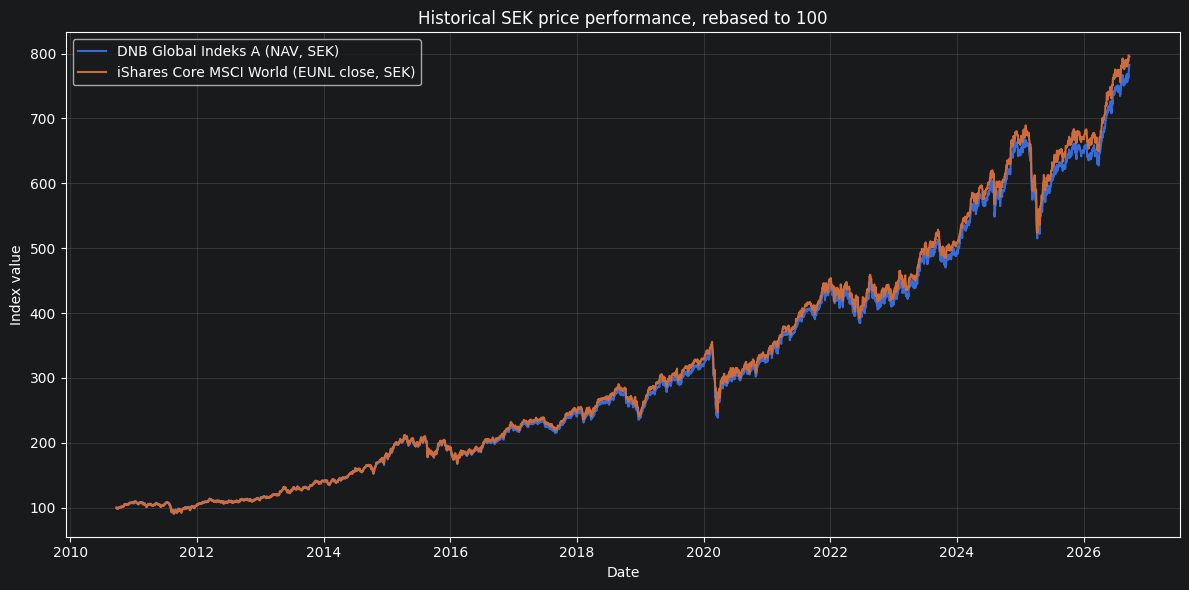

,series,total_return_pct,annualized_return_pct
0,DNB Global Indeks A,682.493926,13.729006
1,iShares Core MSCI World (EUNL),695.371558,13.845151


In [31]:
aligned["dnb_index_100"] = aligned.dnb_nav_sek / aligned.dnb_nav_sek.iloc[0] * 100
aligned["ishares_index_100"] = aligned.ishares_close_sek / aligned.ishares_close_sek.iloc[0] * 100

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(aligned.date, aligned.dnb_index_100, label="DNB Global Indeks A (NAV, SEK)")
ax.plot(aligned.date, aligned.ishares_index_100, label="iShares Core MSCI World (EUNL close, SEK)")
ax.set(title="Historical SEK price performance, rebased to 100", ylabel="Index value", xlabel="Date")
ax.grid(True, alpha=.25)
ax.legend()
apply_plot_window(ax)
plt.tight_layout()
plt.show()

years = (aligned.date.iloc[-1] - aligned.date.iloc[0]).days / 365.25
performance_summary = pd.DataFrame({
    "series": ["DNB Global Indeks A", "iShares Core MSCI World (EUNL)"],
    "total_return_pct": [(aligned.dnb_index_100.iloc[-1] / 100 - 1) * 100,
                         (aligned.ishares_index_100.iloc[-1] / 100 - 1) * 100],
    "annualized_return_pct": [(aligned.dnb_index_100.iloc[-1] / 100) ** (1/years) * 100 - 100,
                              (aligned.ishares_index_100.iloc[-1] / 100) ** (1/years) * 100 - 100],
})
performance_summary.to_csv(DATA_DIR / "historical_performance_summary.csv", index=False)
performance_summary


## EUNL vs Länsförsäkringar Global Index

Länsförsäkringar Global Index (ISIN SE0005188836) is priced in SEK, so it is compared directly with EUNL converted to SEK using the aligned ECB rates. Both series are rebased to 100 on their first common date, and the chart and return table use that same shared period. If its NAV CSV is missing, the notebook downloads daily NAV history from Morningstar. Sources: [Länsförsäkringar fund facts](https://lf.fondlista.se/en/1/details/SE0005188836) and [Morningstar fund page](https://www.morningstar.se/se/funds/snapshot/snapshot.aspx?id=F00000PYZ6&tab=1).


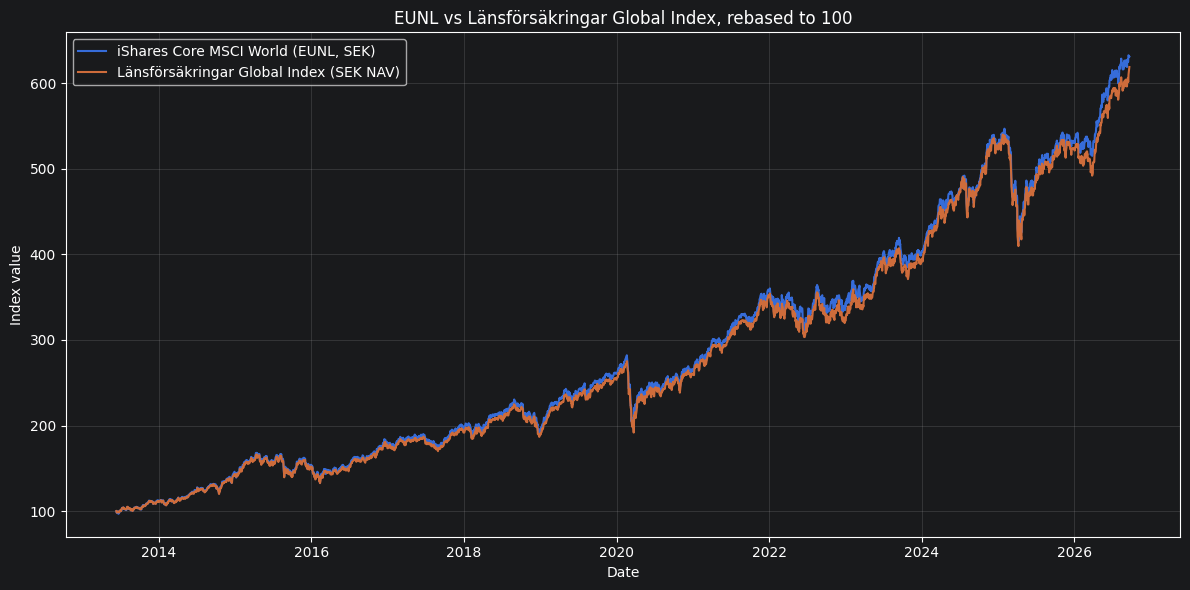

,series,start_date,end_date,total_return_pct,annualized_return_pct
0,iShares Core MSCI World (EUNL),2013-06-11,2026-09-21,530.917666,14.880248
1,Länsförsäkringar Global Index,2013-06-11,2026-09-21,518.778300,14.712286


In [32]:
lf_nav_path = DATA_DIR / "lansforsakringar_global_index_nav_sek.csv"
if not lf_nav_path.exists():
    refresh_lansforsakringar_nav()

lf = pd.read_csv(lf_nav_path, parse_dates=["date"])
lf["nav_sek"] = pd.to_numeric(lf["nav_sek"], errors="coerce")
lf = lf.dropna(subset=["date", "nav_sek"]).sort_values("date")
assert lf.date.is_unique and lf.date.is_monotonic_increasing
assert (lf.nav_sek > 0).all()

lf_comparison = pd.merge_asof(
    aligned[["date", "ishares_close_sek"]].sort_values("date"),
    lf.rename(columns={"date": "lf_nav_date"}).sort_values("lf_nav_date"),
    left_on="date", right_on="lf_nav_date", direction="backward",
).dropna(subset=["ishares_close_sek", "nav_sek"]).reset_index(drop=True)
if lf_comparison.empty:
    raise ValueError("Länsförsäkringar NAV history does not overlap the EUNL price history.")
lf_comparison["eunl_index_100"] = lf_comparison.ishares_close_sek / lf_comparison.ishares_close_sek.iloc[0] * 100
lf_comparison["lansforsakringar_index_100"] = lf_comparison.nav_sek / lf_comparison.nav_sek.iloc[0] * 100

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(lf_comparison.date, lf_comparison.eunl_index_100, label="iShares Core MSCI World (EUNL, SEK)")
ax.plot(lf_comparison.date, lf_comparison.lansforsakringar_index_100, label="Länsförsäkringar Global Index (SEK NAV)")
ax.set(title="EUNL vs Länsförsäkringar Global Index, rebased to 100", ylabel="Index value", xlabel="Date")
ax.grid(True, alpha=.25)
ax.legend()
apply_plot_window(ax)
plt.tight_layout()
fig.savefig(DATA_DIR / "eunl_vs_lansforsakringar_global_index_sek.png", dpi=160, bbox_inches="tight")
plt.show()

common_years = (lf_comparison.date.iloc[-1] - lf_comparison.date.iloc[0]).days / 365.25
lf_performance_summary = pd.DataFrame({
    "series": ["iShares Core MSCI World (EUNL)", "Länsförsäkringar Global Index"],
    "start_date": [lf_comparison.date.iloc[0].date(), lf_comparison.date.iloc[0].date()],
    "end_date": [lf_comparison.date.iloc[-1].date(), lf_comparison.date.iloc[-1].date()],
    "total_return_pct": [(lf_comparison.eunl_index_100.iloc[-1] / 100 - 1) * 100,
                         (lf_comparison.lansforsakringar_index_100.iloc[-1] / 100 - 1) * 100],
    "annualized_return_pct": [(lf_comparison.eunl_index_100.iloc[-1] / 100) ** (1/common_years) * 100 - 100,
                              (lf_comparison.lansforsakringar_index_100.iloc[-1] / 100) ** (1/common_years) * 100 - 100],
})
lf_comparison.to_csv(DATA_DIR / "eunl_vs_lansforsakringar_global_index_sek.csv", index=False, date_format="%Y-%m-%d")
lf_performance_summary


## Monthly contribution simulation

One equal SEK contribution is added at each month-end. The latest aligned observation on or before that month-end is used. ETF buys include the estimated half-spread, IBKR commission, and an FX fee on conversion. Unused EUR from whole-share buys remains as cash and is included in ending value.


In [33]:
def affordable_etf_quantity(cash_eur, buy_price_eur):
    if cash_eur <= IBKR_MIN_COMMISSION_EUR:
        return 0.0
    q_min = (cash_eur - IBKR_MIN_COMMISSION_EUR) / buy_price_eur
    if q_min <= 0:
        return 0.0
    if q_min * buy_price_eur * IBKR_COMMISSION_RATE <= IBKR_MIN_COMMISSION_EUR:
        quantity = q_min
    else:
        quantity = cash_eur / (buy_price_eur * (1 + IBKR_COMMISSION_RATE))
    return max(0.0, quantity if ETF_ALLOW_FRACTIONAL_SHARES else math.floor(quantity))

sim_start = pd.Timestamp(SIMULATION_START_DATE) if SIMULATION_START_DATE else aligned.date.min()
sim_end = pd.Timestamp(SIMULATION_END_DATE) if SIMULATION_END_DATE else aligned.date.max()
sim = aligned.loc[(aligned.date >= sim_start) & (aligned.date <= sim_end)].set_index("date").sort_index()
if sim.empty:
    raise ValueError("The selected simulation window does not overlap the common history.")
contribution_dates = pd.date_range(sim.index.min(), sim.index.max(), freq="ME")
if len(contribution_dates) == 0:
    raise ValueError("The selected simulation window has no month-end dates.")

dnb_units = dnb_cash = etf_units = etf_cash_eur = 0.0
records = []
six_month_records = []
for month_number, deposit_date in enumerate(contribution_dates, start=1):
    row = sim.loc[:deposit_date].iloc[-1]
    contribution = MONTHLY_CONTRIBUTION_SEK
    dnb_mid = float(row.dnb_nav_sek)
    etf_mid = float(row.close_eur)
    eur_sek = float(row.sek_per_eur)

    dnb_cash += contribution
    dnb_fee = min(AVANZA_FUND_ORDER_FEE_SEK, dnb_cash)
    dnb_bought = max(0.0, (dnb_cash - dnb_fee) / dnb_mid)
    if dnb_bought > 0:
        dnb_units += dnb_bought
        dnb_cash -= dnb_bought * dnb_mid + dnb_fee
    else:
        dnb_fee = 0.0

    fx_fee_sek = contribution * IBKR_AUTO_FX_FEE_RATE
    etf_cash_eur += (contribution - fx_fee_sek) / eur_sek
    buy_price = etf_mid * (1 + ETF_FULL_SPREAD_RATE / 2)
    bought = affordable_etf_quantity(etf_cash_eur, buy_price)
    traded_eur = bought * buy_price
    commission_eur = max(IBKR_MIN_COMMISSION_EUR, traded_eur * IBKR_COMMISSION_RATE) if bought > 0 else 0.0
    if traded_eur + commission_eur > etf_cash_eur + 1e-8:
        raise ArithmeticError("ETF order is larger than available EUR cash.")
    etf_units += bought
    etf_cash_eur -= traded_eur + commission_eur

    records.append({
        "contribution_date": deposit_date.date(),
        "price_observation_date": row.name.date(),
        "contribution_sek": contribution,
        "dnb_nav_sek": dnb_mid,
        "dnb_units_bought": dnb_bought,
        "dnb_order_fee_sek": dnb_fee,
        "etf_close_eur": etf_mid,
        "etf_buy_price_eur": buy_price,
        "eur_sek": eur_sek,
        "etf_units_bought": bought,
        "etf_commission_eur": commission_eur,
        "etf_fx_fee_sek": fx_fee_sek,
        "etf_spread_cost_sek": bought * (buy_price - etf_mid) * eur_sek,
    })

    if month_number % 6 == 0 or month_number == len(contribution_dates):
        dnb_value = dnb_units * dnb_mid + dnb_cash
        etf_value = (etf_units * etf_mid + etf_cash_eur) * eur_sek
        paid_to_date = MONTHLY_CONTRIBUTION_SEK * month_number
        six_month_records.append({
            "months": month_number,
            "valuation_date": row.name,
            "contributions_sek": paid_to_date,
            "dnb_value_sek": dnb_value,
            "dnb_profit_sek": dnb_value - paid_to_date,
            "eunl_value_sek": etf_value,
            "eunl_profit_sek": etf_value - paid_to_date,
        })

monthly_trades = pd.DataFrame(records)
last = sim.iloc[-1]
total_paid = MONTHLY_CONTRIBUTION_SEK * len(monthly_trades)
dnb_end = dnb_units * float(last.dnb_nav_sek) + dnb_cash
etf_end = (etf_units * float(last.close_eur) + etf_cash_eur) * float(last.sek_per_eur)
avanza_fees = monthly_trades.dnb_order_fee_sek.sum()
ibkr_commission_sek = (monthly_trades.etf_commission_eur * monthly_trades.eur_sek).sum()
ibkr_fx_fees = monthly_trades.etf_fx_fee_sek.sum()
spread_cost_sek = monthly_trades.etf_spread_cost_sek.sum()

six_month_progression = pd.DataFrame(six_month_records)
if not six_month_progression.empty and six_month_progression.months.iloc[-1] == len(monthly_trades):
    six_month_progression.loc[six_month_progression.index[-1], "valuation_date"] = sim.index[-1]
    six_month_progression.loc[six_month_progression.index[-1], "dnb_value_sek"] = dnb_end
    six_month_progression.loc[six_month_progression.index[-1], "dnb_profit_sek"] = dnb_end - total_paid
    six_month_progression.loc[six_month_progression.index[-1], "eunl_value_sek"] = etf_end
    six_month_progression.loc[six_month_progression.index[-1], "eunl_profit_sek"] = etf_end - total_paid
six_month_progression["absolute_difference_sek"] = (six_month_progression.eunl_value_sek - six_month_progression.dnb_value_sek).abs()
six_month_progression["difference_vs_dnb_pct"] = six_month_progression.absolute_difference_sek / six_month_progression.dnb_value_sek * 100

simulation_summary = pd.DataFrame([
    {"route":"DNB Global Indeks A via Avanza ISK","contributions_sek":total_paid,
     "ending_value_sek":dnb_end,"profit_sek":dnb_end-total_paid,
     "order_fees_sek":avanza_fees,"ibkr_commission_sek":0,
     "estimated_spread_cost_sek":0,"fx_conversion_fees_sek":0,
     "units_held":dnb_units,"ending_cash_sek":dnb_cash},
    {"route":"iShares EUNL via IBKR ISK","contributions_sek":total_paid,
     "ending_value_sek":etf_end,"profit_sek":etf_end-total_paid,
     "order_fees_sek":0,"ibkr_commission_sek":ibkr_commission_sek,
     "estimated_spread_cost_sek":spread_cost_sek,"fx_conversion_fees_sek":ibkr_fx_fees,
     "units_held":etf_units,"ending_cash_sek":etf_cash_eur*float(last.sek_per_eur)},
])
simulation_summary = simulation_summary.rename(columns={
    "route": "Route", "contributions_sek": "Contributions (SEK)",
    "ending_value_sek": "Ending value (SEK)", "profit_sek": "Profit (SEK)",
    "order_fees_sek": "Order fees (SEK)", "ibkr_commission_sek": "IBKR commission (SEK)",
    "estimated_spread_cost_sek": "Estimated spread cost (SEK)",
    "fx_conversion_fees_sek": "FX conversion fees (SEK)",
    "units_held": "Units held", "ending_cash_sek": "Ending cash (SEK)",
})
simulation_summary[["Route", "Contributions (SEK)", "Ending value (SEK)", "Profit (SEK)"]].style.format({
    "Contributions (SEK)": "{:,.0f}", "Ending value (SEK)": "{:,.0f}",
    "Profit (SEK)": "{:,.0f}",
}).hide(axis="index")


Route,Contributions (SEK),Ending value (SEK),Profit (SEK)
DNB Global Indeks A via Avanza ISK,"4,800,000","17,111,384","12,311,384"
iShares EUNL via IBKR ISK,"4,800,000","17,195,510","12,395,510"


## Six-month progression

The table marks the portfolio at every six contributions, plus the final month when the simulation ends between checkpoints. Values include invested holdings and any uninvested cash. Profit is portfolio value minus contributions paid so far. The chart compares both routes with the amount contributed.


Months,Valuation date,Contributions (SEK),DNB value (SEK),DNB profit (SEK),EUNL value (SEK),EUNL profit (SEK),Absolute difference (SEK),Difference vs DNB (%)
6,2011-02-28 00:00:00,"150,000","154,730","4,730","153,370","3,370","1,359",0.88%
12,2011-08-31 00:00:00,"300,000","280,034","-19,966","281,358","-18,642","1,325",0.47%
18,2012-02-29 00:00:00,"450,000","472,933","22,933","473,580","23,580",647,0.14%
24,2012-08-31 00:00:00,"600,000","623,383","23,383","624,008","24,008",625,0.10%
30,2013-02-28 00:00:00,"750,000","829,728","79,728","827,400","77,400","2,327",0.28%
36,2013-08-30 00:00:00,"900,000","1,054,742","154,742","1,051,017","151,017","3,725",0.35%
42,2014-02-28 00:00:00,"1,050,000","1,320,611","270,611","1,326,008","276,008","5,397",0.41%
48,2014-08-29 00:00:00,"1,200,000","1,669,590","469,590","1,677,315","477,315","7,725",0.46%
54,2015-02-27 00:00:00,"1,350,000","2,207,166","857,166","2,229,285","879,285","22,118",1.00%
60,2015-08-31 00:00:00,"1,500,000","2,257,123","757,123","2,264,830","764,830","7,707",0.34%


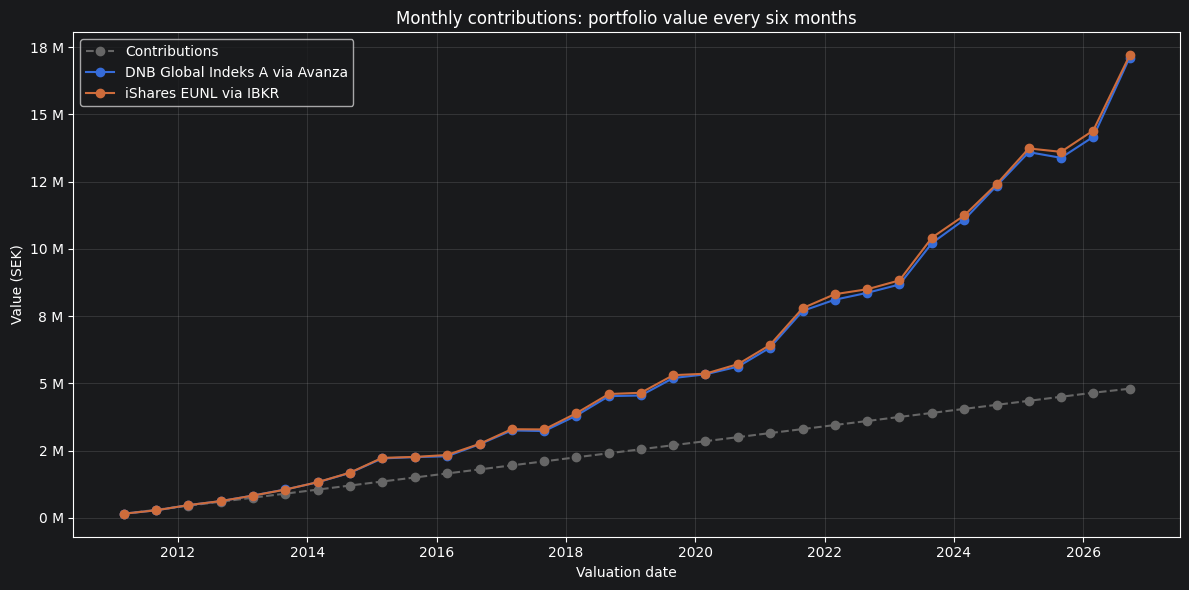

In [34]:
from IPython.display import display

progression_display = six_month_progression.rename(columns={
    "months": "Months", "valuation_date": "Valuation date",
    "contributions_sek": "Contributions (SEK)",
    "dnb_value_sek": "DNB value (SEK)", "dnb_profit_sek": "DNB profit (SEK)",
    "eunl_value_sek": "EUNL value (SEK)", "eunl_profit_sek": "EUNL profit (SEK)",
    "absolute_difference_sek": "Absolute difference (SEK)",
    "difference_vs_dnb_pct": "Difference vs DNB (%)",
})
progression_display.to_csv(DATA_DIR / "six_month_progression.csv", index=False, date_format="%Y-%m-%d")
display(progression_display.style.format({
    "Contributions (SEK)": "{:,.0f}", "DNB value (SEK)": "{:,.0f}",
    "DNB profit (SEK)": "{:,.0f}", "EUNL value (SEK)": "{:,.0f}",
    "EUNL profit (SEK)": "{:,.0f}", "Absolute difference (SEK)": "{:,.0f}",
    "Difference vs DNB (%)": "{:,.2f}%",
}).hide(axis="index"))

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(six_month_progression.valuation_date, six_month_progression.contributions_sek,
        color="#666666", linestyle="--", marker="o", label="Contributions")
ax.plot(six_month_progression.valuation_date, six_month_progression.dnb_value_sek,
        marker="o", label="DNB Global Indeks A via Avanza")
ax.plot(six_month_progression.valuation_date, six_month_progression.eunl_value_sek,
        marker="o", label="iShares EUNL via IBKR")
ax.set(title="Monthly contributions: portfolio value every six months",
       xlabel="Valuation date", ylabel="Value (SEK)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value/1_000_000:.0f} M"))
ax.grid(True, alpha=.25)
ax.legend()
apply_plot_window(ax)
plt.tight_layout()
fig.savefig(DATA_DIR / "six_month_progression.png", dpi=160, bbox_inches="tight")
fig.savefig(DATA_DIR / "six_month_progression.svg", bbox_inches="tight")
plt.show()


## Fees and cost breakdown

IBKR’s published European tiered commission schedule is modeled as 0.05% with a EUR 1.25 minimum; its automatic currency conversion rate adjustment is modeled at 0.03%. The default ETF spread is an editable estimate, not a historical spread feed. Verify current IBKR and Avanza terms for your account before relying on these assumptions.


In [35]:
cost_breakdown = pd.DataFrame([
    {"cost":"Avanza fund order fee","assumption":f"{AVANZA_FUND_ORDER_FEE_SEK:.2f} SEK/order","total_sek":avanza_fees,"treatment":"Deducted per fund purchase"},
    {"cost":"DNB A ongoing cost","assumption":f"{DNB_ONGOING_COST_RATE:.2%}/year","total_sek":np.nan,"treatment":"Already reflected in NAV"},
    {"cost":"IBKR ETF commission","assumption":f"{IBKR_COMMISSION_RATE:.2%}, minimum EUR {IBKR_MIN_COMMISSION_EUR:.2f}","total_sek":ibkr_commission_sek,"treatment":"Deducted per ETF purchase"},
    {"cost":"ETF full spread estimate","assumption":f"{ETF_FULL_SPREAD_RATE:.2%}","total_sek":spread_cost_sek,"treatment":"Half-spread added to buy price"},
    {"cost":"IBKR automatic FX fee","assumption":f"{IBKR_AUTO_FX_FEE_RATE:.2%} of SEK converted","total_sek":ibkr_fx_fees,"treatment":"Deducted from each monthly contribution"},
    {"cost":"iShares ongoing cost","assumption":f"{ISHARES_ONGOING_COST_RATE:.2%}/year","total_sek":np.nan,"treatment":"Already reflected in ETF price/NAV"},
])
cost_breakdown.to_csv(DATA_DIR / "cost_breakdown.csv", index=False)
monthly_trades.to_csv(DATA_DIR / "monthly_investment_trades.csv", index=False, date_format="%Y-%m-%d")
simulation_summary.to_csv(DATA_DIR / "monthly_investment_results.csv", index=False)
cost_breakdown


,cost,assumption,total_sek,treatment
0,Avanza fund order fee,0.00 SEK/order,0.000000,Deducted per fund purchase
1,DNB A ongoing cost,0.20%/year,NaN,Already reflected in NAV
2,IBKR ETF commission,"0.05%, minimum EUR 1.25",2500.286994,Deducted per ETF purchase
3,ETF full spread estimate,0.10%,2396.241937,Half-spread added to buy price
4,IBKR automatic FX fee,0.03% of SEK converted,1440.000000,Deducted from each monthly contribution
5,iShares ongoing cost,0.20%/year,NaN,Already reflected in ETF price/NAV


## World + emerging-markets portfolio: IBKR vs Avanza

Compare a two-fund portfolio using iShares Core MSCI World UCITS ETF USD (Acc) (ISIN IE00B4L5Y983) and iShares Core MSCI Emerging Markets IMI UCITS ETF (Acc) (ISIN IE00BKM4GZ66) on IBKR, against DNB Global Indeks S and DNB Global Emerging Markets Indeks S on Avanza. The SEK share classes are used for Avanza price histories, so no Avanza FX transaction fee is modeled. The default Xetra listings are EUNL.DE and IS3N.DE, both quoted in EUR; IBKR's currency conversion and order commission are modeled.

The default split is 90% World / 10% emerging markets and can be changed below. Each new monthly contribution uses that split; existing holdings are not periodically rebalanced. The spread assumptions are editable estimates, charged as half-spread on ETF buys only. Fund NAVs and ETF prices already reflect fund-level costs; those are not deducted again. The historical performance chart excludes broker execution costs, while the contribution simulation applies them. Taxes and sale costs are excluded. Data sources: [iShares World](https://www.ishares.com/uk/individual/en/products/251882/ishares-msci-world-ucits-etf), [iShares EM IMI](https://www.ishares.com/uk/individual/en/products/264659/ishares-msci-emerging-markets-imi-ucits-etf), [DNB Global](https://www.dnb.no/en/saving/mutual-funds/dnb-global-index), [DNB Global Emerging Markets Index](https://www.dnb.no/sparing/fond/fond-liste/d/dnb-global-emerging-markets-index-a-NO0010815855), [IBKR European commissions](https://www.interactivebrokers.com/en/pricing/commissions-stocks.php), and [IBKR FX pricing](https://brokerage.ibkr.com/en/pricing/commissions-spot-currencies.php).

The Avanza leg uses the SEK-distributed share classes DNB Global Indeks S (ISIN NO0010827280) and DNB Global Emerging Markets Indeks S (ISIN NO0012740150). Avanza's public fund chart data (references 1509082 and 1509081) returns cumulative percentages, which are converted to synthetic SEK index levels rebased to 100. The unit counts in the contribution simulation are therefore synthetic, while portfolio values remain scale-invariant. ETF close prices use Yahoo Finance and ECB reference rates convert EUR to SEK for valuation; these are daily price proxies, not executable broker fills.

**Monthly contributions.** The simulation uses the notebook's monthly contribution and date window. Each deposit is allocated by `WORLD_WEIGHT` and `EM_WEIGHT`. Avanza mutual-fund purchases use fractional units at the SEK NAV with no broker FX fee or spread charge. IBKR buys the EUR-listed ETFs, applies automatic FX conversion, tiered commission (including the minimum), and the estimated half-spread. Whole ETF shares are used unless `ETF_ALLOW_FRACTIONAL_SHARES` is enabled. Cash not invested in whole shares remains part of portfolio value.


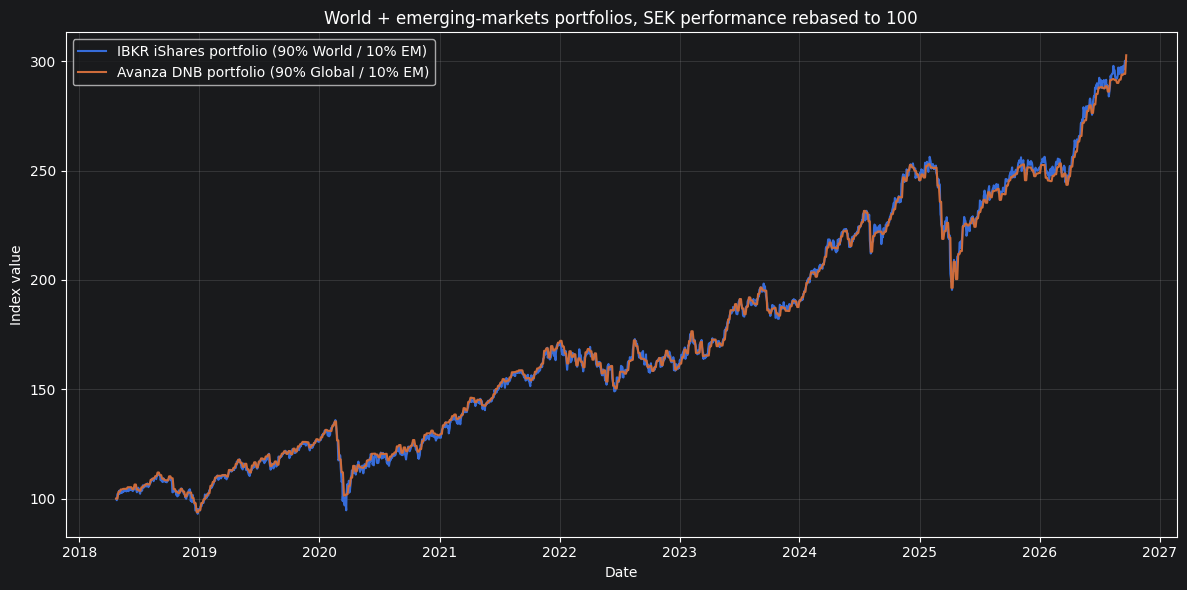

,route,start_date,end_date,total_return_pct,annualized_return_pct
0,IBKR iShares ETFs,2018-04-23,2026-09-21,200.056177,13.951290
1,Avanza DNB funds,2018-04-23,2026-09-21,202.782571,14.073864


In [36]:
# Editable inputs for this two-fund comparison
DNB_GLOBAL_INDEX_AVANZA_ID = 1509082
DNB_EM_INDEX_AVANZA_ID = 1509081

if not np.isclose(WORLD_WEIGHT + EM_WEIGHT, 1.0) or min(WORLD_WEIGHT, EM_WEIGHT) < 0:
    raise ValueError("WORLD_WEIGHT and EM_WEIGHT must be nonnegative and sum to 1.")

def refresh_portfolio_yahoo(ticker, output_path, price_column):
    start = int(datetime(2000, 1, 1, tzinfo=timezone.utc).timestamp())
    end = int((datetime.now(timezone.utc) + timedelta(days=1)).timestamp())
    url = (f"https://query1.finance.yahoo.com/v8/finance/chart/{ticker}"
           f"?period1={start}&period2={end}&interval=1d&events=history")
    payload = json.loads(get_bytes(url, "application/json"))
    err = payload.get("chart", {}).get("error")
    if err:
        raise RuntimeError(err)
    result = payload["chart"]["result"][0]
    close = result["indicators"]["quote"][0].get("close", [])
    rows = [{"date": datetime.fromtimestamp(stamp, timezone.utc).date().isoformat(),
             price_column: close[i]}
            for i, stamp in enumerate(result.get("timestamp", []))
            if i < len(close) and close[i] is not None]
    pd.DataFrame(rows).to_csv(output_path, index=False)

def refresh_portfolio_avanza_chart(fund_id, output_path):
    url = f"https://www.avanza.se/_api/fund-guide/chart/{fund_id}/infinity"
    payload = json.loads(get_bytes(url, "application/json"))
    series = payload.get("dataSerie", [])
    rows = [{"date": datetime.fromtimestamp(point["x"] / 1000, timezone.utc).date().isoformat(),
             "nav_sek": 100 * (1 + float(point["y"]) / 100)}
            for point in series if point.get("x") is not None and point.get("y") is not None]
    if not rows:
        raise RuntimeError(f"Avanza returned no SEK chart history for fund reference {fund_id}.")
    pd.DataFrame(rows).to_csv(output_path, index=False)

portfolio_files = {
    "world_etf": DATA_DIR / "ishares_core_msci_world_eunl_xetra_eur.csv",
    "em_etf": DATA_DIR / "ishares_core_msci_em_imi_is3n_xetra_eur.csv",
    "dnb_global": DATA_DIR / "dnb_global_index_s_nav_sek.csv",
    "dnb_em": DATA_DIR / "dnb_global_em_index_s_nav_sek.csv",
}
if REFRESH_DATA or not portfolio_files["world_etf"].exists():
    refresh_portfolio_yahoo("EUNL.DE", portfolio_files["world_etf"], "close_eur")
if REFRESH_DATA or not portfolio_files["em_etf"].exists():
    refresh_portfolio_yahoo("IS3N.DE", portfolio_files["em_etf"], "close_eur")
if REFRESH_DATA or not portfolio_files["dnb_global"].exists():
    refresh_portfolio_avanza_chart(DNB_GLOBAL_INDEX_AVANZA_ID, portfolio_files["dnb_global"])
if REFRESH_DATA or not portfolio_files["dnb_em"].exists():
    refresh_portfolio_avanza_chart(DNB_EM_INDEX_AVANZA_ID, portfolio_files["dnb_em"])

world_hist = pd.read_csv(portfolio_files["world_etf"], parse_dates=["date"])[["date", "close_eur"]]
em_hist = pd.read_csv(portfolio_files["em_etf"], parse_dates=["date"])[["date", "close_eur"]]
dnb_world_hist = pd.read_csv(portfolio_files["dnb_global"], parse_dates=["date"])[["date", "nav_sek"]]
dnb_em_hist = pd.read_csv(portfolio_files["dnb_em"], parse_dates=["date"])[["date", "nav_sek"]]
portfolio_fx = pd.read_csv(DATA_DIR / "ecb_daily_eur_fx.csv", parse_dates=["date"])[["date", "sek_per_eur"]]
for frame, column in [(world_hist, "close_eur"), (em_hist, "close_eur"),
                      (dnb_world_hist, "nav_sek"), (dnb_em_hist, "nav_sek"),
                      (portfolio_fx, "sek_per_eur")]:
    frame[column] = pd.to_numeric(frame[column], errors="coerce")
    frame.dropna(subset=["date", column], inplace=True)
    frame.sort_values("date", inplace=True)
    if frame.date.duplicated().any():
        raise ValueError(f"Duplicate dates in source series for {column}.")

portfolio_start = max(frame.date.min() for frame in [world_hist, em_hist, dnb_world_hist, dnb_em_hist, portfolio_fx])
portfolio_end = min(frame.date.max() for frame in [world_hist, em_hist, dnb_world_hist, dnb_em_hist, portfolio_fx])
portfolio_calendar = pd.DataFrame({"date": pd.date_range(portfolio_start, portfolio_end, freq="B")})
portfolio_aligned = portfolio_calendar
for source, rename in [
    (world_hist.rename(columns={"date":"world_price_date", "close_eur":"world_eur"}), "world"),
    (em_hist.rename(columns={"date":"em_price_date", "close_eur":"em_eur"}), "em"),
    (dnb_world_hist.rename(columns={"date":"dnb_world_nav_date", "nav_sek":"dnb_world_sek"}), "dnb_world"),
    (dnb_em_hist.rename(columns={"date":"dnb_em_nav_date", "nav_sek":"dnb_em_sek"}), "dnb_em"),
    (portfolio_fx.rename(columns={"date":"fx_date"}), "fx"),
]:
    date_col = {"world":"world_price_date", "em":"em_price_date", "dnb_world":"dnb_world_nav_date",
                "dnb_em":"dnb_em_nav_date", "fx":"fx_date"}[rename]
    portfolio_aligned = pd.merge_asof(portfolio_aligned.sort_values("date"), source.sort_values(date_col),
                                      left_on="date", right_on=date_col, direction="backward")
portfolio_aligned = portfolio_aligned.dropna(subset=["world_eur", "em_eur", "dnb_world_sek", "dnb_em_sek", "sek_per_eur"]).reset_index(drop=True)
portfolio_aligned["world_etf_sek"] = portfolio_aligned.world_eur * portfolio_aligned.sek_per_eur
portfolio_aligned["em_etf_sek"] = portfolio_aligned.em_eur * portfolio_aligned.sek_per_eur
portfolio_aligned["ibkr_portfolio_index_100"] = (
    WORLD_WEIGHT * portfolio_aligned.world_etf_sek / portfolio_aligned.world_etf_sek.iloc[0] +
    EM_WEIGHT * portfolio_aligned.em_etf_sek / portfolio_aligned.em_etf_sek.iloc[0]) * 100
portfolio_aligned["avanza_portfolio_index_100"] = (
    WORLD_WEIGHT * portfolio_aligned.dnb_world_sek / portfolio_aligned.dnb_world_sek.iloc[0] +
    EM_WEIGHT * portfolio_aligned.dnb_em_sek / portfolio_aligned.dnb_em_sek.iloc[0]) * 100
portfolio_aligned.to_csv(DATA_DIR / "world_em_portfolio_performance_sek.csv", index=False, date_format="%Y-%m-%d")

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(portfolio_aligned.date, portfolio_aligned.ibkr_portfolio_index_100,
        label=f"IBKR iShares portfolio ({WORLD_WEIGHT:.0%} World / {EM_WEIGHT:.0%} EM)")
ax.plot(portfolio_aligned.date, portfolio_aligned.avanza_portfolio_index_100,
        label=f"Avanza DNB portfolio ({WORLD_WEIGHT:.0%} Global / {EM_WEIGHT:.0%} EM)")
ax.set(title="World + emerging-markets portfolios, SEK performance rebased to 100",
       ylabel="Index value", xlabel="Date")
ax.grid(True, alpha=.25)
ax.legend()
apply_plot_window(ax)
plt.tight_layout()
plt.show()

portfolio_years = (portfolio_aligned.date.iloc[-1] - portfolio_aligned.date.iloc[0]).days / 365.25
portfolio_performance_summary = pd.DataFrame({
    "route": ["IBKR iShares ETFs", "Avanza DNB funds"],
    "start_date": [portfolio_aligned.date.iloc[0].date()] * 2,
    "end_date": [portfolio_aligned.date.iloc[-1].date()] * 2,
    "total_return_pct": [portfolio_aligned.ibkr_portfolio_index_100.iloc[-1] - 100,
                         portfolio_aligned.avanza_portfolio_index_100.iloc[-1] - 100],
    "annualized_return_pct": [(portfolio_aligned.ibkr_portfolio_index_100.iloc[-1] / 100) ** (1/portfolio_years) * 100 - 100,
                              (portfolio_aligned.avanza_portfolio_index_100.iloc[-1] / 100) ** (1/portfolio_years) * 100 - 100],
})
portfolio_performance_summary.to_csv(DATA_DIR / "world_em_portfolio_performance_summary.csv", index=False)
portfolio_performance_summary


In [37]:
portfolio_sim_start = max(pd.Timestamp(SIMULATION_START_DATE) if SIMULATION_START_DATE else portfolio_aligned.date.min(), portfolio_aligned.date.min())
portfolio_sim_end = min(pd.Timestamp(SIMULATION_END_DATE) if SIMULATION_END_DATE else portfolio_aligned.date.max(), portfolio_aligned.date.max())
portfolio_sim = portfolio_aligned.loc[(portfolio_aligned.date >= portfolio_sim_start) &
                                      (portfolio_aligned.date <= portfolio_sim_end)].set_index("date").sort_index()
if portfolio_sim.empty:
    raise ValueError("The selected simulation window does not overlap World + EM portfolio history.")
portfolio_contribution_dates = pd.date_range(portfolio_sim.index.min(), portfolio_sim.index.max(), freq="ME")
if len(portfolio_contribution_dates) == 0:
    raise ValueError("The selected World + EM simulation window has no month-end dates.")

av_world_units = av_em_units = 0.0
ib_world_units = ib_em_units = 0.0
ib_world_cash_eur = ib_em_cash_eur = 0.0
portfolio_records = []
for month_number, deposit_date in enumerate(portfolio_contribution_dates, start=1):
    row = portfolio_sim.loc[:deposit_date].iloc[-1]
    contribution = MONTHLY_CONTRIBUTION_SEK
    av_world_buy_sek = contribution * WORLD_WEIGHT
    av_em_buy_sek = contribution * EM_WEIGHT
    av_world_fee = min(AVANZA_FUND_ORDER_FEE_SEK, av_world_buy_sek)
    av_em_fee = min(AVANZA_FUND_ORDER_FEE_SEK, av_em_buy_sek)
    av_world_units += max(0.0, (av_world_buy_sek - av_world_fee) / float(row.dnb_world_sek))
    av_em_units += max(0.0, (av_em_buy_sek - av_em_fee) / float(row.dnb_em_sek))

    fx_sek = float(row.sek_per_eur)
    ib_world_cash_eur += contribution * WORLD_WEIGHT * (1 - IBKR_AUTO_FX_FEE_RATE) / fx_sek
    ib_em_cash_eur += contribution * EM_WEIGHT * (1 - IBKR_AUTO_FX_FEE_RATE) / fx_sek
    world_buy_price = float(row.world_eur) * (1 + ETF_FULL_SPREAD_RATE / 2)
    em_buy_price = float(row.em_eur) * (1 + ETF_FULL_SPREAD_RATE / 2)
    ib_world_bought = affordable_etf_quantity(ib_world_cash_eur, world_buy_price)
    ib_em_bought = affordable_etf_quantity(ib_em_cash_eur, em_buy_price)
    world_traded = ib_world_bought * world_buy_price
    em_traded = ib_em_bought * em_buy_price
    world_commission = max(IBKR_MIN_COMMISSION_EUR, world_traded * IBKR_COMMISSION_RATE) if ib_world_bought else 0.0
    em_commission = max(IBKR_MIN_COMMISSION_EUR, em_traded * IBKR_COMMISSION_RATE) if ib_em_bought else 0.0
    if world_traded + world_commission > ib_world_cash_eur + 1e-8 or em_traded + em_commission > ib_em_cash_eur + 1e-8:
        raise ArithmeticError("An ETF order is larger than the allocated EUR cash.")
    ib_world_units += ib_world_bought
    ib_em_units += ib_em_bought
    ib_world_cash_eur -= world_traded + world_commission
    ib_em_cash_eur -= em_traded + em_commission
    portfolio_records.append({
        "contribution_date": deposit_date.date(), "price_observation_date": row.name.date(),
        "contribution_sek": contribution, "sek_per_eur": fx_sek, "avanza_world_purchase_sek": av_world_buy_sek,
        "avanza_em_purchase_sek": av_em_buy_sek, "avanza_fund_order_fees_sek": av_world_fee + av_em_fee,
        "ibkr_fx_fee_sek": contribution * IBKR_AUTO_FX_FEE_RATE,
        "world_etf_units_bought": ib_world_bought, "em_etf_units_bought": ib_em_bought,
        "ibkr_commission_eur": world_commission + em_commission,
        "world_spread_cost_sek": ib_world_bought * (world_buy_price - float(row.world_eur)) * fx_sek,
        "em_spread_cost_sek": ib_em_bought * (em_buy_price - float(row.em_eur)) * fx_sek,
    })
portfolio_monthly_trades = pd.DataFrame(portfolio_records)
portfolio_last = portfolio_sim.iloc[-1]
portfolio_total_paid = MONTHLY_CONTRIBUTION_SEK * len(portfolio_monthly_trades)
avanza_portfolio_fees = float(portfolio_monthly_trades.avanza_fund_order_fees_sek.sum())
avanza_portfolio_end = av_world_units * float(portfolio_last.dnb_world_sek) + av_em_units * float(portfolio_last.dnb_em_sek)
ibkr_portfolio_end = (ib_world_units * float(portfolio_last.world_eur) + ib_world_cash_eur +
                      ib_em_units * float(portfolio_last.em_eur) + ib_em_cash_eur) * float(portfolio_last.sek_per_eur)
portfolio_broker_costs = pd.DataFrame([
    {"route":"Avanza DNB funds", "fund_order_fees_sek":avanza_portfolio_fees,
     "commission_sek":0.0, "estimated_spread_sek":0.0, "fx_fees_sek":0.0,
     "ongoing_cost_rates_disclosure":f"DNB Global Indeks S {DNB_ONGOING_COST_RATE:.2%}; DNB EM Index S {DNB_EM_ONGOING_COST_RATE:.2%}"},
    {"route":"IBKR iShares ETFs", "fund_order_fees_sek":0.0,
     "commission_sek":float((portfolio_monthly_trades.ibkr_commission_eur * portfolio_monthly_trades.sek_per_eur).sum()),
     "estimated_spread_sek":float(portfolio_monthly_trades.world_spread_cost_sek.sum() + portfolio_monthly_trades.em_spread_cost_sek.sum()),
     "fx_fees_sek":float(portfolio_monthly_trades.ibkr_fx_fee_sek.sum()),
     "ongoing_cost_rates_disclosure":f"World {ISHARES_ONGOING_COST_RATE:.2%}; EM IMI {ISHARES_EM_ONGOING_COST_RATE:.2%}"},
])
portfolio_simulation_summary = pd.DataFrame([
    {"route":"Avanza: DNB Global Indeks S + DNB Global Emerging Markets Indeks S",
     "contributions_sek":portfolio_total_paid, "ending_value_sek":avanza_portfolio_end,
     "profit_sek":avanza_portfolio_end-portfolio_total_paid,
     "ending_cash_sek":0.0, "order_fees_sek":avanza_portfolio_fees, "commission_sek":0.0,
     "estimated_spread_sek":0.0, "fx_fees_sek":0.0},
    {"route":"IBKR: iShares World + EM IMI ETFs",
     "contributions_sek":portfolio_total_paid, "ending_value_sek":ibkr_portfolio_end,
     "profit_sek":ibkr_portfolio_end-portfolio_total_paid,
     "ending_cash_sek":(ib_world_cash_eur+ib_em_cash_eur)*float(portfolio_last.sek_per_eur),
     "order_fees_sek":0.0,
     "commission_sek":float((portfolio_monthly_trades.ibkr_commission_eur * portfolio_monthly_trades.sek_per_eur).sum()),
     "estimated_spread_sek":float(portfolio_monthly_trades.world_spread_cost_sek.sum()+portfolio_monthly_trades.em_spread_cost_sek.sum()),
     "fx_fees_sek":float(portfolio_monthly_trades.ibkr_fx_fee_sek.sum())},
])
portfolio_simulation_summary.to_csv(DATA_DIR / "world_em_monthly_simulation_results.csv", index=False)
portfolio_monthly_trades.to_csv(DATA_DIR / "world_em_monthly_trades.csv", index=False, date_format="%Y-%m-%d")
display(portfolio_simulation_summary)
display(portfolio_broker_costs)


,route,contributions_sek,ending_value_sek,profit_sek,ending_cash_sek,order_fees_sek,commission_sek,estimated_spread_sek,fx_fees_sek
0,Avanza: DNB Global Indeks S + DNB Global Emerg...,2525000.0,4.860973e+06,2.335973e+06,0.000000,0.0,0.000,0.000000,0.0
1,IBKR: iShares World + EM IMI ETFs,2525000.0,4.824805e+06,2.299805e+06,1336.760464,0.0,2726.375,1259.473065,757.5


,route,fund_order_fees_sek,commission_sek,estimated_spread_sek,fx_fees_sek,ongoing_cost_rates_disclosure
0,Avanza DNB funds,0.0,0.000,0.000000,0.0,DNB Global Indeks S 0.20%; DNB EM Index S 0.30%
1,IBKR iShares ETFs,0.0,2726.375,1259.473065,757.5,World 0.20%; EM IMI 0.18%


## Conclusions from the current results

This section summarizes the results produced above. Rerun the notebook from top to bottom after changing data, dates, allocation, contributions, or fee assumptions to refresh these conclusions.


In [38]:
from IPython.display import Markdown, display


def format_sek(value):
    return f"SEK {value:,.0f}"


def format_pct(value):
    return f"{value:.2f}%"


def historical_finding(summary, title, date_range):
    winner = summary.loc[summary["annualized_return_pct"].idxmax()]
    runner_up = summary.loc[summary["annualized_return_pct"].idxmin()]
    gap = winner["annualized_return_pct"] - runner_up["annualized_return_pct"]
    if np.isclose(gap, 0):
        comparison = f"Both series had the same annualized return ({format_pct(winner['annualized_return_pct'])})"
    else:
        comparison = (
            f"{winner['series']} had the higher annualized return "
            f"({format_pct(winner['annualized_return_pct'])} vs "
            f"{format_pct(runner_up['annualized_return_pct'])}), a gap of {format_pct(gap)}"
        )
    return (
        f"- **{title} ({date_range}):** {comparison}. "
        f"Their cumulative returns were {format_pct(winner['total_return_pct'])} and "
        f"{format_pct(runner_up['total_return_pct'])}, respectively."
    )


def portfolio_historical_finding(summary, title):
    winner = summary.loc[summary["annualized_return_pct"].idxmax()]
    runner_up = summary.loc[summary["annualized_return_pct"].idxmin()]
    gap = winner["annualized_return_pct"] - runner_up["annualized_return_pct"]
    dates = f"{winner['start_date']} to {winner['end_date']}"
    if np.isclose(gap, 0):
        comparison = f"Both routes had the same annualized return ({format_pct(winner['annualized_return_pct'])})"
    else:
        comparison = (
            f"{winner['route']} had the higher annualized return "
            f"({format_pct(winner['annualized_return_pct'])} vs "
            f"{format_pct(runner_up['annualized_return_pct'])}), a gap of {format_pct(gap)}"
        )
    return (
        f"- **{title} ({dates}):** {comparison}. "
        f"Cumulative returns were {format_pct(winner['total_return_pct'])} and "
        f"{format_pct(runner_up['total_return_pct'])}, respectively."
    )


def contribution_finding(summary, route_column, value_column, profit_column,
                         contribution_column, title, cost_columns=()):
    winner = summary.loc[summary[value_column].idxmax()]
    runner_up = summary.loc[summary[value_column].idxmin()]
    difference = float(winner[value_column] - runner_up[value_column])
    invested = float(winner[contribution_column])
    if np.isclose(difference, 0):
        comparison = f"both routes finished level at {format_sek(winner[value_column])}"
    else:
        comparison = (
            f"{winner[route_column]} finished with the higher simulated value "
            f"({format_sek(winner[value_column])} vs {format_sek(runner_up[value_column])})"
        )
    lines = [
        f"- **{title}:** {comparison}, a difference of {format_sek(difference)} "
        f"after {format_sek(invested)} in contributions. "
        f"Simulated profits were {format_sek(winner[profit_column])} and "
        f"{format_sek(runner_up[profit_column])}, respectively."
    ]
    if cost_columns:
        winner_cost = sum(float(winner[column]) for column in cost_columns)
        runner_cost = sum(float(runner_up[column]) for column in cost_columns)
        lines.append(
            f"  Modeled transaction costs were {format_sek(winner_cost)} for the higher-value route "
            f"and {format_sek(runner_cost)} for the other route."
        )
    return "\n".join(lines)


dnb_dates = f"{aligned.date.iloc[0].date()} to {aligned.date.iloc[-1].date()}"
lf_dates = f"{lf_comparison.date.iloc[0].date()} to {lf_comparison.date.iloc[-1].date()}"

conclusion_lines = [
    historical_finding(performance_summary, "DNB Global Indeks A vs EUNL", dnb_dates),
    historical_finding(lf_performance_summary, "EUNL vs Länsförsäkringar Global Index", lf_dates),
    contribution_finding(
        simulation_summary, "Route", "Ending value (SEK)", "Profit (SEK)",
        "Contributions (SEK)", "Monthly contributions: DNB A vs EUNL",
        ("Order fees (SEK)", "IBKR commission (SEK)",
         "Estimated spread cost (SEK)", "FX conversion fees (SEK)"),
    ),
    portfolio_historical_finding(
        portfolio_performance_summary, "World + emerging-markets portfolios"
    ),
    contribution_finding(
        portfolio_simulation_summary, "route", "ending_value_sek", "profit_sek",
        "contributions_sek", "World + emerging-markets monthly contributions",
        ("order_fees_sek", "commission_sek", "estimated_spread_sek", "fx_fees_sek"),
    ),
]

caveat = (
    "\n\nThese are historical comparisons for the periods shown, not forecasts. "
    "The historical return charts omit broker execution costs; the contribution simulations include "
    "the modeled costs described above. Results depend on the chosen allocation, dates, and fee assumptions."
)
display(Markdown("\n\n".join(conclusion_lines) + caveat))


- **DNB Global Indeks A vs EUNL (2010-09-24 to 2026-09-21):** iShares Core MSCI World (EUNL) had the higher annualized return (13.85% vs 13.73%), a gap of 0.12%. Their cumulative returns were 695.37% and 682.49%, respectively.

- **EUNL vs Länsförsäkringar Global Index (2013-06-11 to 2026-09-21):** iShares Core MSCI World (EUNL) had the higher annualized return (14.88% vs 14.71%), a gap of 0.17%. Their cumulative returns were 530.92% and 518.78%, respectively.

- **Monthly contributions: DNB A vs EUNL:** iShares EUNL via IBKR ISK finished with the higher simulated value (SEK 17,195,510 vs SEK 17,111,384), a difference of SEK 84,126 after SEK 4,800,000 in contributions. Simulated profits were SEK 12,395,510 and SEK 12,311,384, respectively.
  Modeled transaction costs were SEK 6,337 for the higher-value route and SEK 0 for the other route.

- **World + emerging-markets portfolios (2018-04-23 to 2026-09-21):** Avanza DNB funds had the higher annualized return (14.07% vs 13.95%), a gap of 0.12%. Cumulative returns were 202.78% and 200.06%, respectively.

- **World + emerging-markets monthly contributions:** Avanza: DNB Global Indeks S + DNB Global Emerging Markets Indeks S finished with the higher simulated value (SEK 4,860,973 vs SEK 4,824,805), a difference of SEK 36,168 after SEK 2,525,000 in contributions. Simulated profits were SEK 2,335,973 and SEK 2,299,805, respectively.
  Modeled transaction costs were SEK 0 for the higher-value route and SEK 4,743 for the other route.

These are historical comparisons for the periods shown, not forecasts. The historical return charts omit broker execution costs; the contribution simulations include the modeled costs described above. Results depend on the chosen allocation, dates, and fee assumptions.